In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
import os

print(os.getcwd())

c:\Users\DELL\Documents\Dell\Customer-Segmentation-Churn-Analytics\notebooks


In [4]:
import os

print(os.listdir(".."))

['app.py', 'data', 'notebooks', 'README.md', 'requirements.txt']


In [5]:
import pandas as pd

df = pd.read_csv("../data/Churn_Modelling.csv")

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
print("Shape:", df.shape)
df.info()

Shape: (10000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [7]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

df.head()

KeyError: "['RowNumber'] not found in axis"

In [9]:
print(df.columns)

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')


In [10]:
df = df.drop(['CustomerId', 'Surname'], axis=1)

df.head()

,Year,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
churn_rate = df['Exited'].mean() * 100
print("Overall Churn Rate:", round(churn_rate, 2), "%")

Overall Churn Rate: 20.37 %


In [12]:
geo_churn = pd.crosstab(
    df['Geography'],
    df['Exited'],
    normalize='index'
) * 100

geo_churn

Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395


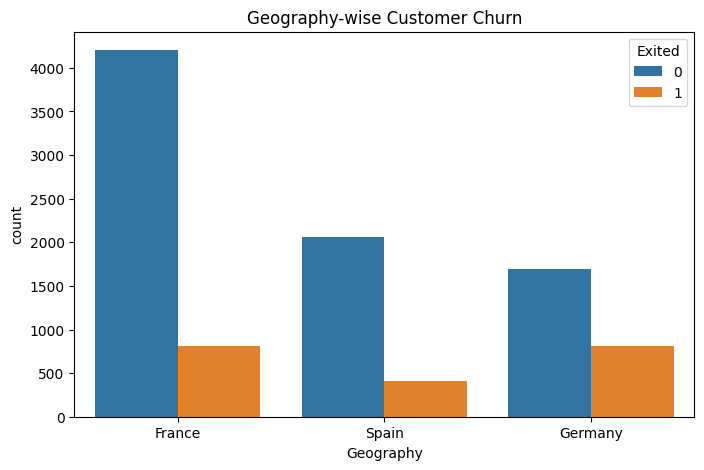

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Geography',
    hue='Exited',
    data=df
)

plt.title("Geography-wise Customer Churn")
plt.show()

In [14]:
df.groupby('Geography')['Exited'].mean()*100

Geography
France     16.154767
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

In [15]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,30,45,60,100],
    labels=['<30','30-45','46-60','60+']
)

In [16]:
df.groupby('AgeGroup')['Exited'].mean()*100

AgeGroup
<30       7.520325
30-45    15.740584
46-60    51.123254
60+      24.784483
Name: Exited, dtype: float64

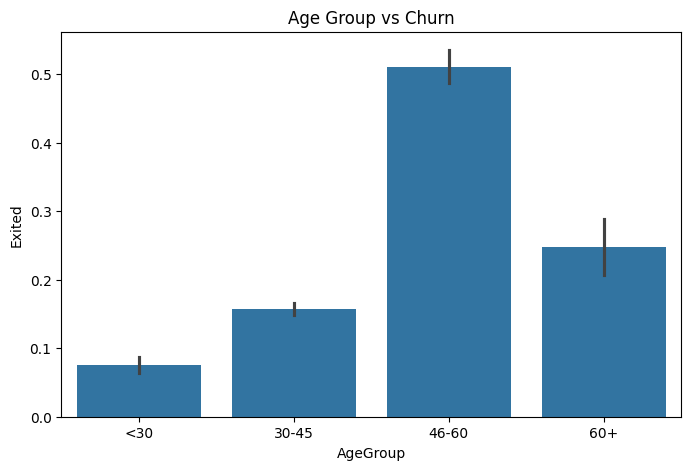

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='AgeGroup',
    y='Exited',
    data=df
)

plt.title("Age Group vs Churn")
plt.show()

In [18]:
df.groupby('Gender')['Exited'].mean()*100

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

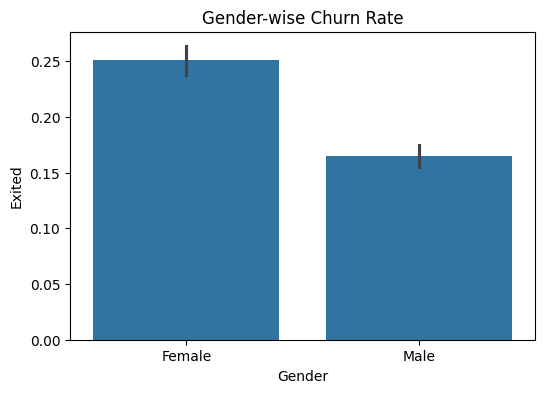

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Exited', data=df)
plt.title("Gender-wise Churn Rate")
plt.show()

In [20]:
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0,30,45,60,100],
    labels=['<30','30-45','46-60','60+']
)

In [21]:
df.groupby('AgeGroup')['Exited'].mean()*100

AgeGroup
<30       7.520325
30-45    15.740584
46-60    51.123254
60+      24.784483
Name: Exited, dtype: float64

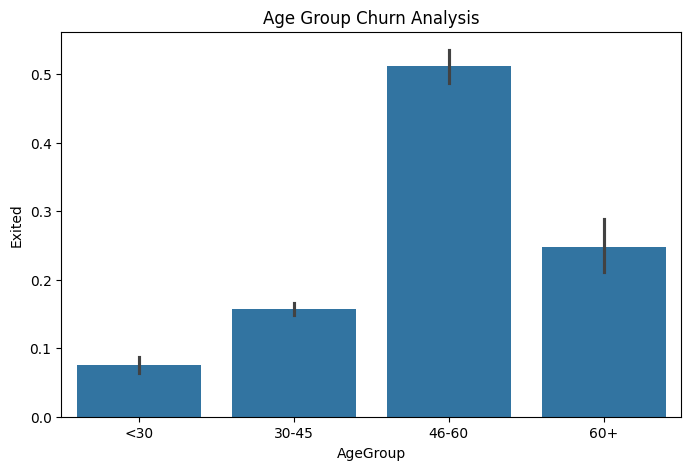

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x='AgeGroup', y='Exited', data=df)
plt.title("Age Group Churn Analysis")
plt.show()

In [23]:
df['CreditBand'] = pd.cut(
    df['CreditScore'],
    bins=[0,500,700,900],
    labels=['Low','Medium','High']
)

In [24]:
df.groupby('CreditBand')['Exited'].mean()*100

CreditBand
Low       23.639191
Medium    20.285211
High      19.865212
Name: Exited, dtype: float64

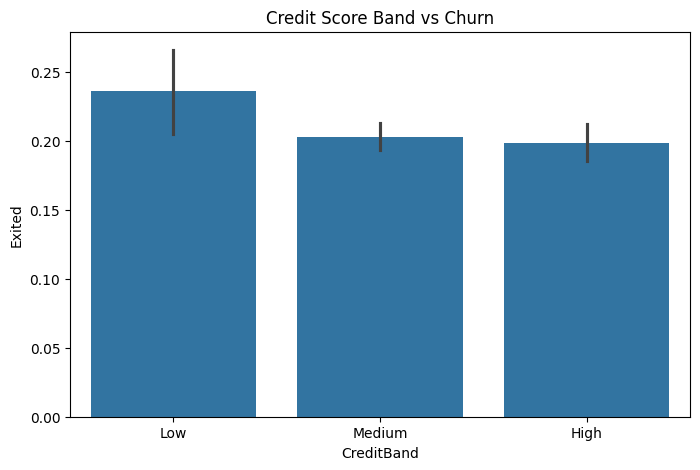

In [25]:
plt.figure(figsize=(8,5))
sns.barplot(x='CreditBand', y='Exited', data=df)
plt.title("Credit Score Band vs Churn")
plt.show()

In [26]:
df['TenureGroup'] = pd.cut(
    df['Tenure'],
    bins=[-1,3,7,10],
    labels=['New','Mid-Term','Long-Term']
)

In [27]:
df.groupby('TenureGroup')['Exited'].mean()*100

TenureGroup
New          21.141227
Mid-Term     19.644645
Long-Term    20.448179
Name: Exited, dtype: float64

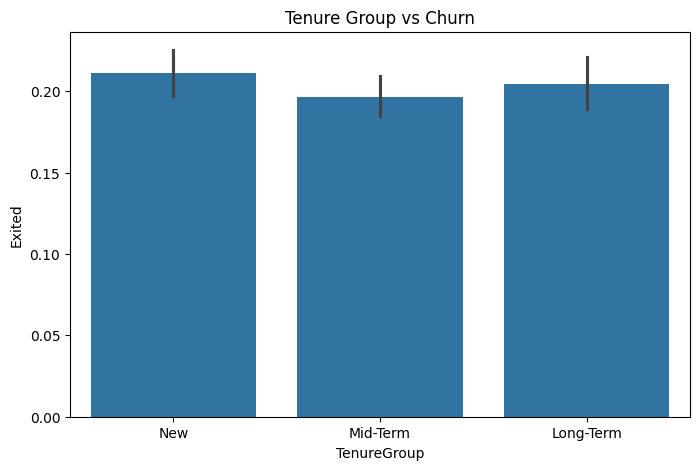

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(x='TenureGroup', y='Exited', data=df)
plt.title("Tenure Group vs Churn")
plt.show()

In [29]:
df['BalanceGroup'] = pd.cut(
    df['Balance'],
    bins=[-1,0,100000,300000],
    labels=['Zero Balance','Low Balance','High Balance']
)

In [30]:
df.groupby('BalanceGroup')['Exited'].mean()*100

BalanceGroup
Zero Balance    13.823611
Low Balance     20.580808
High Balance    25.234424
Name: Exited, dtype: float64

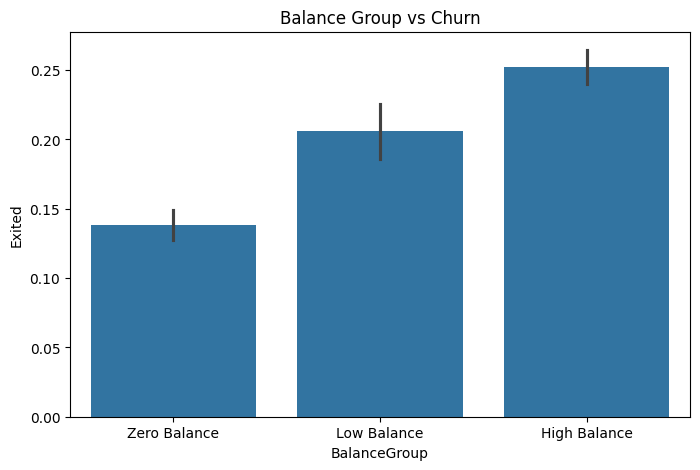

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(x='BalanceGroup', y='Exited', data=df)
plt.title("Balance Group vs Churn")
plt.show()

In [32]:
df.groupby('IsActiveMember')['Exited'].mean()*100

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

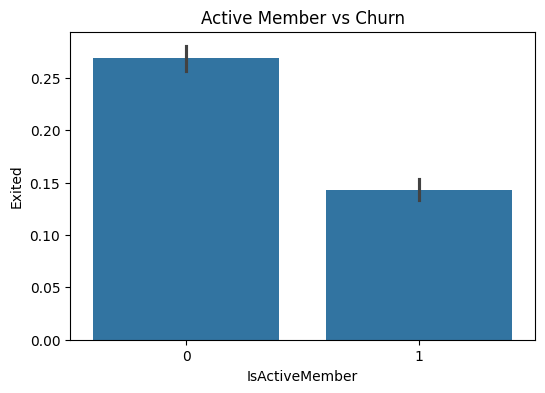

In [33]:
plt.figure(figsize=(6,4))
sns.barplot(x='IsActiveMember', y='Exited', data=df)
plt.title("Active Member vs Churn")
plt.show()

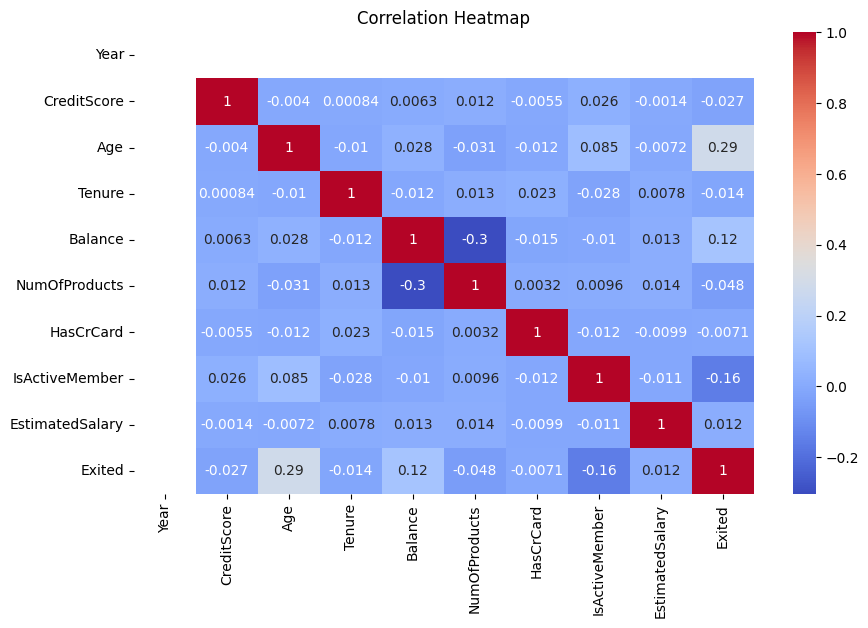

In [34]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [35]:
# Gender
df.groupby('Gender')['Exited'].mean()*100

# Age Group
df.groupby('AgeGroup')['Exited'].mean()*100

# Credit Band
df.groupby('CreditBand')['Exited'].mean()*100

# Tenure Group
df.groupby('TenureGroup')['Exited'].mean()*100

# Balance Group
df.groupby('BalanceGroup')['Exited'].mean()*100

# Active Member
df.groupby('IsActiveMember')['Exited'].mean()*100

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

In [36]:
df.groupby('Gender')['Exited'].mean()*100

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64

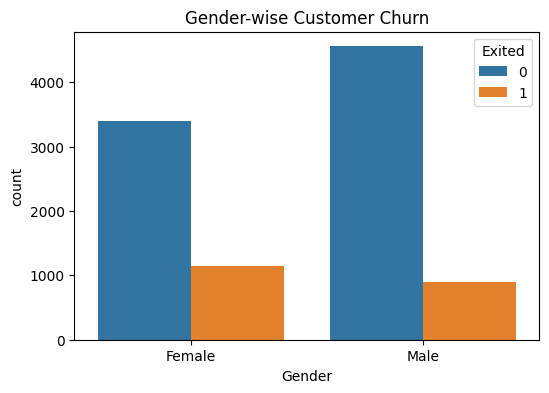

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Exited', data=df)
plt.title("Gender-wise Customer Churn")
plt.show()

In [41]:
df.groupby('IsActiveMember')['Exited'].mean()*100

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

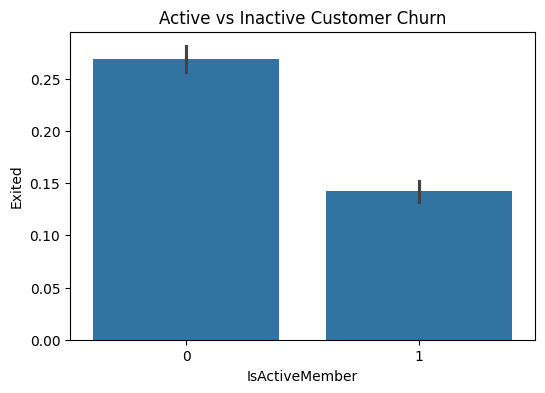

In [42]:
plt.figure(figsize=(6,4))
sns.barplot(x='IsActiveMember', y='Exited', data=df)
plt.title("Active vs Inactive Customer Churn")
plt.show()

In [43]:
premium = df[df['Balance'] > 100000]

print("Premium Customers:", len(premium))
print("Premium Customer Churn Rate:",
      round(premium['Exited'].mean()*100,2), "%")

Premium Customers: 4799
Premium Customer Churn Rate: 25.23 %


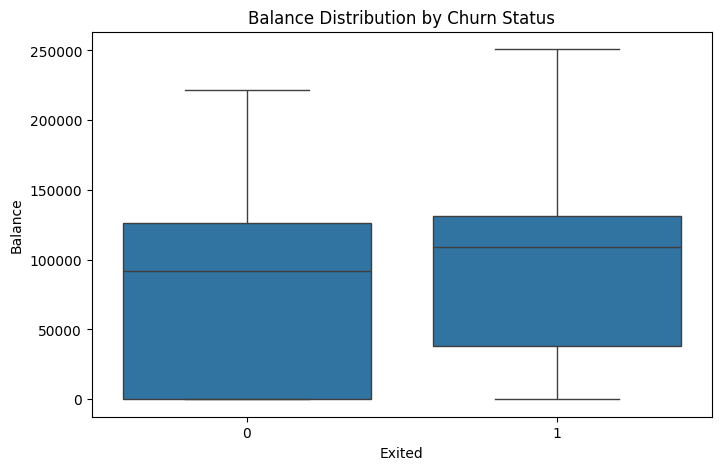

In [44]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='Balance',
    data=df
)

plt.title("Balance Distribution by Churn Status")
plt.show()

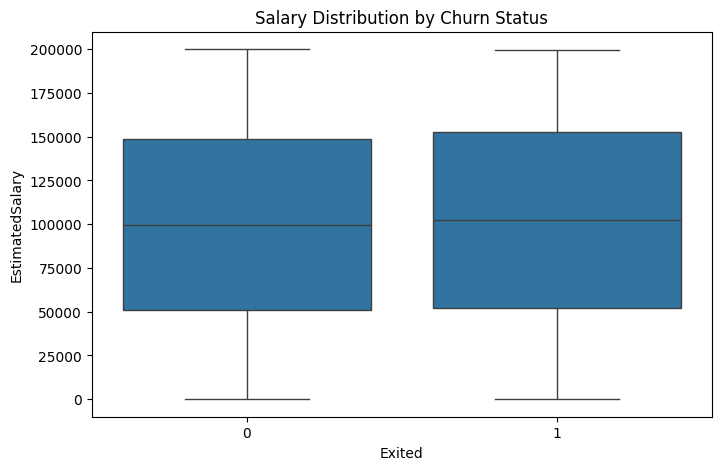

In [45]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Exited',
    y='EstimatedSalary',
    data=df
)

plt.title("Salary Distribution by Churn Status")
plt.show()

In [46]:
df.groupby('NumOfProducts')['Exited'].mean()*100

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

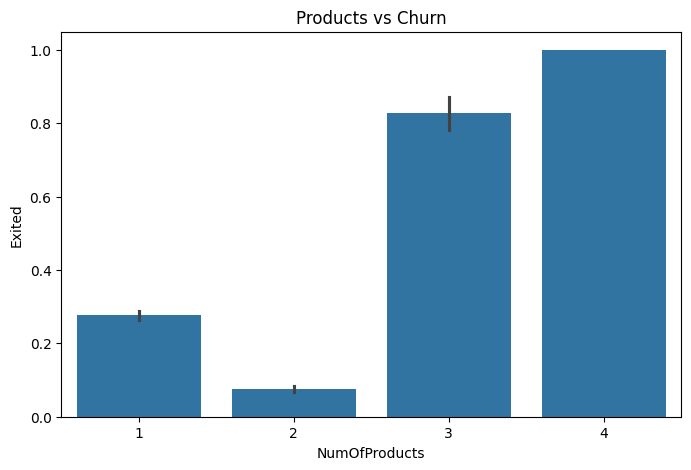

In [47]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='NumOfProducts',
    y='Exited',
    data=df
)

plt.title("Products vs Churn")
plt.show()

In [48]:
df.groupby('HasCrCard')['Exited'].mean()*100

HasCrCard
0    20.814941
1    20.184266
Name: Exited, dtype: float64

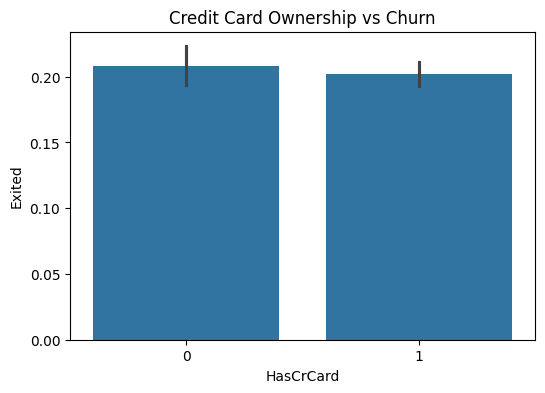

In [49]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='HasCrCard',
    y='Exited',
    data=df
)

plt.title("Credit Card Ownership vs Churn")
plt.show()

In [50]:
total_customers = len(df)

churned = df['Exited'].sum()

retained = total_customers - churned

churn_rate = round(df['Exited'].mean()*100,2)

print("Total Customers:", total_customers)
print("Churned Customers:", churned)
print("Retained Customers:", retained)
print("Overall Churn Rate:", churn_rate,"%")

Total Customers: 10000
Churned Customers: 2037
Retained Customers: 7963
Overall Churn Rate: 20.37 %
